# Day 4 Lab — Multivariate Detection and Calibrated Fusion

This notebook now tracks the restored Day 4 agenda more directly:
1. inspect **lead/lag** and lightweight **coherence** structure in a metric panel,
2. build complementary branches: **PCA**, **AE**, **template/DTW**, and a real **multivariate Matrix Profile** review path,
3. compare simple fusion baselines against **validation-calibrated** fusion layers,
4. measure what changes when Matrix Profile is added to the fusion stack,
5. review top anomalous windows with branch-level interpretation.

The teaching goal is not “throw more models at the panel.”
It is to show why multivariate anomaly work becomes a problem of **relationship checks, branch diversity, calibration, and explanation**.

## Real-data schema
- required: `timestamp` plus 2 or more metric columns
- optional: `is_anomaly`


In [9]:
from pathlib import Path
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

try:
    import stumpy
    STUMPY_AVAILABLE = True
except Exception:
    stumpy = None
    STUMPY_AVAILABLE = False

plt.style.use('seaborn-v0_8-whitegrid')
SEED = 11
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CSV_PATH = None  # replace with a local CSV path when moving to real data
EXPORT_FIGURES = True
MATRIX_PROFILE_MAX_WINDOWS = 1800  # exact educational path; larger panels should use stumpy if available

def resolve_pack_root():
    cwd = Path.cwd().resolve()
    for candidate in [cwd, cwd.parent]:
        if (candidate / 'notebooks').exists() and (candidate / 'slides').exists():
            return candidate
    return cwd

PACK_ROOT = resolve_pack_root()
FIG_DIR = PACK_ROOT / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

print('device =', device)
print('CSV_PATH =', CSV_PATH)
print('STUMPY_AVAILABLE =', STUMPY_AVAILABLE)


device = cpu
CSV_PATH = None
STUMPY_AVAILABLE = False


## Step 1 — Load a multivariate panel

The synthetic demo intentionally includes several anomaly styles:
- a correlated magnitude shift,
- a single-channel deviation,
- and a collective drift.

This is useful because no single branch should own every anomaly family.

In [10]:
def make_synthetic_panel(n=1200, freq='1min'):
    ts = pd.date_range('2024-01-01', periods=n, freq=freq)
    base = np.sin(np.linspace(0, 12 * np.pi, n))
    seasonal = 0.3 * np.sin(np.linspace(0, 2 * np.pi, n))

    m1 = 0.60 * base + seasonal + np.random.normal(0, 0.05, n)
    m2 = 0.55 * np.roll(base, 2) + 0.7 * seasonal + np.random.normal(0, 0.05, n)
    m3 = -0.35 * base + 0.5 * seasonal + np.random.normal(0, 0.05, n)

    labels = np.zeros(n, dtype=int)
    m1[720:760] += 1.0
    m2[724:764] += 0.75
    labels[720:764] = 1

    m3[880:930] -= 0.70
    labels[880:930] = 1

    m1[1020:1060] += np.linspace(0.0, 0.8, 40)
    m2[1022:1062] += np.linspace(0.0, 0.5, 40)
    labels[1020:1062] = 1

    return pd.DataFrame({'timestamp': ts, 'm1': m1, 'm2': m2, 'm3': m3, 'is_anomaly': labels})


def load_panel(csv_path=None):
    if csv_path and Path(csv_path).exists():
        df = pd.read_csv(csv_path, parse_dates=['timestamp']).sort_values('timestamp')
        if 'is_anomaly' not in df.columns:
            df['is_anomaly'] = 0
        return df
    return make_synthetic_panel()


panel_df = load_panel(CSV_PATH)
metric_cols = [c for c in panel_df.columns if c not in {'timestamp', 'is_anomaly'}]
print(panel_df.head())
print('metrics =', metric_cols)

            timestamp        m1        m2        m3  is_anomaly
0 2024-01-01 00:00:00  0.087473 -0.027783 -0.076104           0
1 2024-01-01 00:01:00  0.006131 -0.145289  0.059887           0
2 2024-01-01 00:02:00  0.016622  0.026968  0.005012           0
3 2024-01-01 00:03:00 -0.071438  0.021330  0.060384           0
4 2024-01-01 00:04:00  0.081136  0.060532 -0.124698           0
metrics = ['m1', 'm2', 'm3']


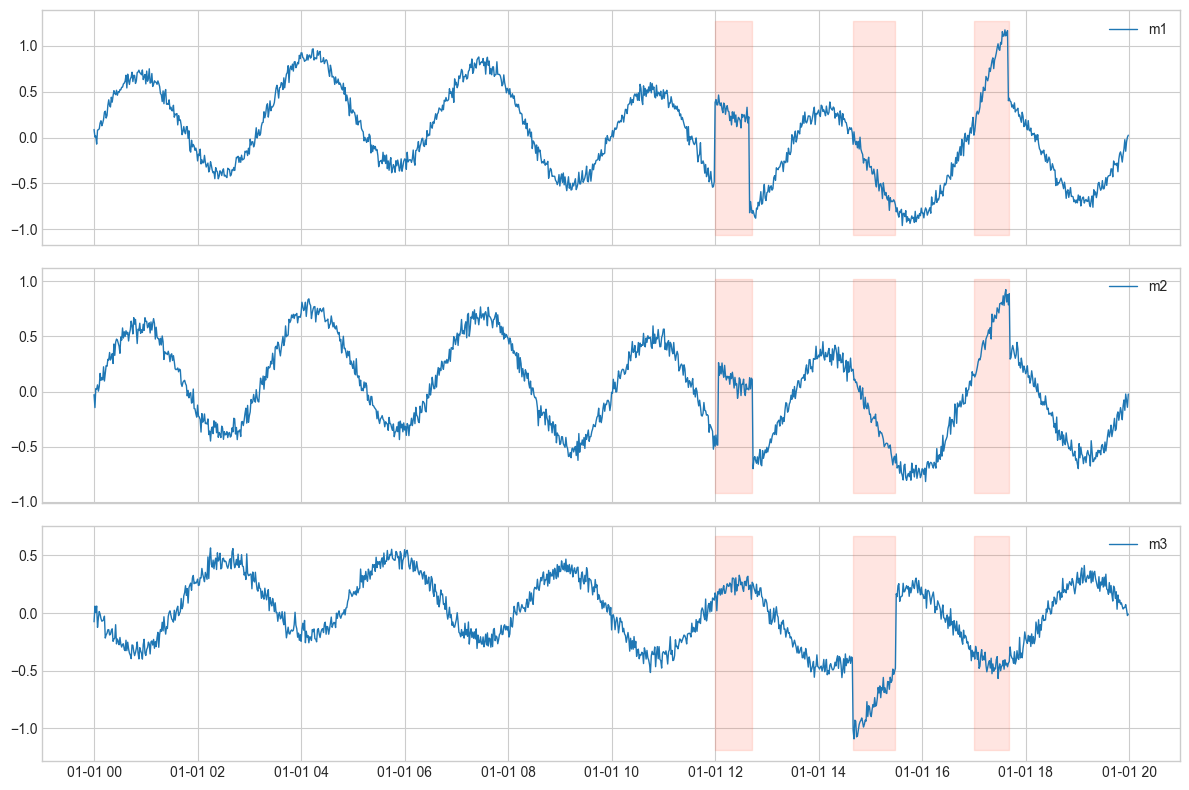

In [11]:
fig, axes = plt.subplots(len(metric_cols), 1, figsize=(12, 8), sharex=True)
for ax, col in zip(axes, metric_cols):
    ax.plot(panel_df['timestamp'], panel_df[col], lw=1.0, label=col)
    ax.fill_between(
        panel_df['timestamp'],
        panel_df[col].min() - 0.1,
        panel_df[col].max() + 0.1,
        where=panel_df['is_anomaly'].astype(bool),
        color='tomato',
        alpha=0.16,
    )
    ax.legend(loc='upper right')
plt.tight_layout()
if EXPORT_FIGURES:
    fig.savefig(FIG_DIR / 'day4_panel_overview.png', dpi=160, bbox_inches='tight')
plt.show()

Lead/lag summary:
    pair  best_abs_corr  best_lag  signed_corr
m1 vs m2          0.976        -3        0.976
m2 vs m3          0.536        -3       -0.536
m1 vs m3          0.461        -2       -0.461

Coherence summary (low-frequency band):
    pair  mean_coherence  peak_coherence
m1 vs m2           0.399           0.996
m1 vs m3           0.134           0.899
m2 vs m3           0.123           0.885


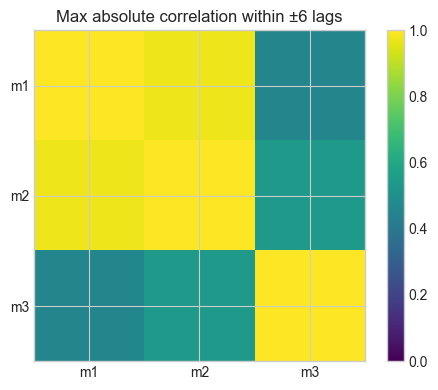

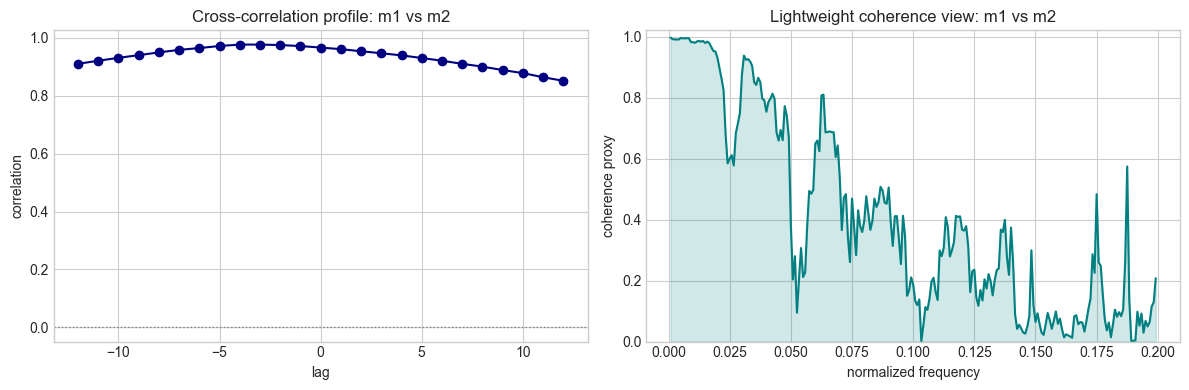

In [12]:
def max_lag_corr_matrix(df, columns, max_lag=6):
    out = pd.DataFrame(0.0, index=columns, columns=columns)
    for i, c1 in enumerate(columns):
        for j, c2 in enumerate(columns):
            if i == j:
                out.loc[c1, c2] = 1.0
                continue
            best = 0.0
            s1 = df[c1].to_numpy()
            s2 = df[c2].to_numpy()
            for lag in range(-max_lag, max_lag + 1):
                if lag < 0:
                    a, b = s1[:lag], s2[-lag:]
                elif lag > 0:
                    a, b = s1[lag:], s2[:-lag]
                else:
                    a, b = s1, s2
                corr = float(np.corrcoef(a, b)[0, 1])
                best = max(best, abs(corr))
            out.loc[c1, c2] = best
    return out


def lag_pair_summary(df, columns, max_lag=12):
    rows = []
    for i, c1 in enumerate(columns):
        for j, c2 in enumerate(columns):
            if i >= j:
                continue
            s1 = df[c1].to_numpy()
            s2 = df[c2].to_numpy()
            best = None
            for lag in range(-max_lag, max_lag + 1):
                if lag < 0:
                    a, b = s1[:lag], s2[-lag:]
                elif lag > 0:
                    a, b = s1[lag:], s2[:-lag]
                else:
                    a, b = s1, s2
                corr = float(np.corrcoef(a, b)[0, 1])
                candidate = (abs(corr), lag, corr)
                if best is None or candidate[0] > best[0]:
                    best = candidate
            rows.append({
                'pair': f'{c1} vs {c2}',
                'best_abs_corr': best[0],
                'best_lag': best[1],
                'signed_corr': best[2],
            })
    return pd.DataFrame(rows).sort_values('best_abs_corr', ascending=False)


def cross_correlation_curve(x, y, max_lag=12):
    lags = np.arange(-max_lag, max_lag + 1)
    values = []
    for lag in lags:
        if lag < 0:
            a, b = x[:lag], y[-lag:]
        elif lag > 0:
            a, b = x[lag:], y[:-lag]
        else:
            a, b = x, y
        values.append(float(np.corrcoef(a, b)[0, 1]))
    return lags, np.asarray(values)


def coherence_profile(x, y, smooth=9):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    x = x - x.mean()
    y = y - y.mean()

    fx = np.fft.rfft(x)
    fy = np.fft.rfft(y)
    sxx = np.abs(fx) ** 2
    syy = np.abs(fy) ** 2
    sxy = fx * np.conj(fy)

    kernel = np.ones(smooth, dtype=float) / smooth
    sxx_s = np.convolve(sxx, kernel, mode='same')
    syy_s = np.convolve(syy, kernel, mode='same')
    sxy_s = np.convolve(np.real(sxy), kernel, mode='same') + 1j * np.convolve(np.imag(sxy), kernel, mode='same')

    coh = (np.abs(sxy_s) ** 2) / (sxx_s * syy_s + 1e-12)
    freq = np.fft.rfftfreq(len(x), d=1.0)
    return freq, np.clip(coh, 0.0, 1.0)


def top_band_coherence(df, columns, low=0.0, high=0.20, smooth=9):
    rows = []
    for i, c1 in enumerate(columns):
        for j, c2 in enumerate(columns):
            if i >= j:
                continue
            freq, coh = coherence_profile(df[c1], df[c2], smooth=smooth)
            mask = (freq > low) & (freq < high)
            rows.append({
                'pair': f'{c1} vs {c2}',
                'mean_coherence': float(coh[mask].mean()),
                'peak_coherence': float(coh[mask].max()),
            })
    return pd.DataFrame(rows).sort_values('peak_coherence', ascending=False)


corr = max_lag_corr_matrix(panel_df, metric_cols, max_lag=6)
lag_details = lag_pair_summary(panel_df, metric_cols, max_lag=12)
coherence_df = top_band_coherence(panel_df, metric_cols, low=0.0, high=0.20, smooth=9)

print('Lead/lag summary:')
print(lag_details.round(3).to_string(index=False))
print()
print('Coherence summary (low-frequency band):')
print(coherence_df.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(corr.values, cmap='viridis', vmin=0, vmax=1)
ax.set_xticks(range(len(metric_cols)), metric_cols)
ax.set_yticks(range(len(metric_cols)), metric_cols)
ax.set_title('Max absolute correlation within ±6 lags')
fig.colorbar(im, ax=ax)
plt.tight_layout()
if EXPORT_FIGURES:
    fig.savefig(FIG_DIR / 'day4_lag_correlation.png', dpi=160, bbox_inches='tight')
plt.show()

strongest_pair = lag_details.iloc[0]
left, right = strongest_pair['pair'].split(' vs ')
lags, xcorr = cross_correlation_curve(panel_df[left].to_numpy(), panel_df[right].to_numpy(), max_lag=12)
freq, coh = coherence_profile(panel_df[left].to_numpy(), panel_df[right].to_numpy(), smooth=9)
mask = (freq > 0) & (freq < 0.20)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].axhline(0.0, color='gray', linestyle=':', lw=1)
axes[0].plot(lags, xcorr, marker='o', color='navy')
axes[0].set_title(f'Cross-correlation profile: {left} vs {right}')
axes[0].set_xlabel('lag')
axes[0].set_ylabel('correlation')

axes[1].plot(freq[mask], coh[mask], color='teal')
axes[1].fill_between(freq[mask], 0.0, coh[mask], color='teal', alpha=0.18)
axes[1].set_ylim(0, 1.02)
axes[1].set_title(f'Lightweight coherence view: {left} vs {right}')
axes[1].set_xlabel('normalized frequency')
axes[1].set_ylabel('coherence proxy')
plt.tight_layout()
if EXPORT_FIGURES:
    fig.savefig(FIG_DIR / 'day4_crosscorr_coherence_notebook.png', dpi=160, bbox_inches='tight')
plt.show()


In [13]:
def build_multivariate_windows(df, columns, window=32, train_frac=0.60, val_frac=0.20):
    values = df[columns].to_numpy(dtype=np.float32)
    labels = df['is_anomaly'].to_numpy(dtype=int)
    timestamps = pd.to_datetime(df['timestamp'])

    windows, y, end_times = [], [], []
    for start in range(len(df) - window + 1):
        end = start + window
        windows.append(values[start:end])
        y.append(int(labels[start:end].max()))
        end_times.append(timestamps.iloc[end - 1])

    X = np.asarray(windows, dtype=np.float32)
    y = np.asarray(y, dtype=int)
    end_index = pd.to_datetime(end_times)

    n = len(X)
    n_train = int(n * train_frac)
    n_val = int(n * val_frac)
    train_idx = np.arange(0, n_train)
    val_idx = np.arange(n_train, n_train + n_val)
    test_idx = np.arange(n_train + n_val, n)

    train_fit = X[train_idx][y[train_idx] == 0]
    if len(train_fit) == 0:
        train_fit = X[train_idx]

    mu = train_fit.mean(axis=(0, 1), keepdims=True)
    sigma = train_fit.std(axis=(0, 1), keepdims=True) + 1e-6
    X_scaled = (X - mu) / sigma

    return {
        'X': X_scaled,
        'y': y,
        'end_index': end_index,
        'train_idx': train_idx,
        'val_idx': val_idx,
        'test_idx': test_idx,
        'columns': columns,
    }


def make_loader(array, batch_size=64, shuffle=False):
    tensor = torch.tensor(array, dtype=torch.float32)
    return DataLoader(TensorDataset(tensor), batch_size=batch_size, shuffle=shuffle)


data = build_multivariate_windows(panel_df, metric_cols, window=32)
print(data['X'].shape)

(1169, 32, 3)



In [14]:
class MultiAE(nn.Module):
    def __init__(self, window, n_features, hidden=64, bottleneck=16):
        super().__init__()
        self.window = window
        self.n_features = n_features
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(window * n_features, hidden),
            nn.ReLU(),
            nn.Linear(hidden, bottleneck),
            nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck, hidden),
            nn.ReLU(),
            nn.Linear(hidden, window * n_features),
        )

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        return out.view(-1, self.window, self.n_features)


def train_autoencoder(model, train_loader, val_loader, epochs=5, lr=1e-3):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    loss_fn = nn.MSELoss()
    best_state, best_val = None, float('inf')
    for epoch in range(1, epochs + 1):
        model.train()
        for batch, in train_loader:
            batch = batch.to(device)
            pred = model(batch)
            loss = loss_fn(pred, batch)
            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()
        model.eval()
        with torch.no_grad():
            losses = []
            for batch, in val_loader:
                batch = batch.to(device)
                losses.append(loss_fn(model(batch), batch).item())
            val_loss = float(np.mean(losses))
        print(f'epoch={epoch} val_loss={val_loss:.4f}')
        if val_loss < best_val:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    model.load_state_dict(best_state)
    model.to('cpu')
    return model


def reconstruction_scores(model, X):
    model.eval()
    with torch.no_grad():
        tensor = torch.tensor(X, dtype=torch.float32)
        recon = model(tensor).numpy()
    return np.mean((recon - X) ** 2, axis=(1, 2))


def simple_dtw(a, b, band=8):
    n, m = len(a), len(b)
    band = max(band, abs(n - m))
    dtw = np.full((n + 1, m + 1), np.inf)
    dtw[0, 0] = 0.0
    for i in range(1, n + 1):
        for j in range(max(1, i - band), min(m, i + band) + 1):
            cost = abs(a[i - 1] - b[j - 1])
            dtw[i, j] = cost + min(dtw[i - 1, j], dtw[i, j - 1], dtw[i - 1, j - 1])
    return float(dtw[n, m])


def template_dtw_scores(X, template):
    out = []
    for window in X:
        dist = 0.0
        for channel in range(window.shape[1]):
            dist += simple_dtw(window[:, channel], template[:, channel], band=8)
        out.append(dist)
    return np.asarray(out)


def exact_multivariate_matrix_profile(series, window, exclusion_zone=None):
    values = np.asarray(series, dtype=float)
    n, d = values.shape
    k = n - window + 1
    if k <= 1:
        raise ValueError('Need at least two subsequences for Matrix Profile.')
    if exclusion_zone is None:
        exclusion_zone = max(1, window // 2)

    windows = np.stack([values[i:i + window] for i in range(k)], axis=0)
    mu = windows.mean(axis=1, keepdims=True)
    sigma = windows.std(axis=1, keepdims=True)
    sigma[sigma < 1e-8] = 1e-8
    z_windows = ((windows - mu) / sigma).reshape(k, window * d)

    norms = np.sum(z_windows ** 2, axis=1, keepdims=True)
    dist2 = np.maximum(norms + norms.T - 2.0 * (z_windows @ z_windows.T), 0.0)
    idx = np.arange(k)
    trivial = np.abs(idx[:, None] - idx[None, :]) <= exclusion_zone
    dist2[trivial] = np.inf

    mp = np.sqrt(np.min(dist2, axis=1))
    mpi = np.argmin(dist2, axis=1)
    return mp, mpi


def multivariate_matrix_profile(series, window, exclusion_zone=None, prefer_stumpy=True):
    values = np.asarray(series, dtype=float)
    if values.ndim != 2:
        raise ValueError('series must be 2D: time x metrics')
    k = len(values) - window + 1
    if k < 2:
        raise ValueError('window is too long for the supplied series')
    if exclusion_zone is None:
        exclusion_zone = max(1, window // 2)

    use_stumpy = prefer_stumpy and STUMPY_AVAILABLE and k > MATRIX_PROFILE_MAX_WINDOWS
    if use_stumpy:
        profile, index = stumpy.mstump(values.T, window)
        return np.asarray(profile[-1], dtype=float), np.asarray(index[-1], dtype=int), 'stumpy.mstump'

    if k > MATRIX_PROFILE_MAX_WINDOWS and not STUMPY_AVAILABLE:
        raise ValueError(
            f'Exact Matrix Profile would build a {k}x{k} distance matrix. '
            'Install stumpy or shorten/downsample the panel for larger real-data runs.'
        )

    mp, mpi = exact_multivariate_matrix_profile(values, window, exclusion_zone=exclusion_zone)
    return mp, mpi, 'exact_numpy'


def plot_multivariate_matrix_profile_overview(df, columns, window, mp, mp_index):
    timestamps = pd.to_datetime(df['timestamp'])
    motif_i = int(np.argmin(mp))
    motif_j = int(mp_index[motif_i])
    discord_i = int(np.argmax(mp))

    fig, (ax_top, ax_mp) = plt.subplots(
        2,
        1,
        figsize=(12.5, 7.0),
        sharex=True,
        gridspec_kw={'height_ratios': [1.9, 1.2]},
    )
    offsets = np.arange(len(columns)) * 2.0
    colors = plt.cm.tab10(np.linspace(0, 1, len(columns)))
    for offset, col, color in zip(offsets, columns, colors):
        ax_top.plot(timestamps, df[col] + offset, lw=1.15, color=color, label=col)

    def highlight(start, color, label):
        ax_top.axvspan(
            timestamps.iloc[start],
            timestamps.iloc[start + window - 1],
            color=color,
            alpha=0.18,
            label=label,
        )

    highlight(motif_i, '#22c55e', 'motif window')
    if motif_j != motif_i:
        highlight(motif_j, '#86efac', 'motif match')
    highlight(discord_i, '#ef4444', 'discord window')

    ax_top.set_title('Multivariate series with motif pair and discord from the Matrix Profile branch')
    ax_top.set_ylabel('offset value')
    ax_top.legend(loc='upper left', ncol=min(5, len(columns) + 3), fontsize=8)
    ax_top.grid(alpha=0.22)

    profile_times = timestamps.iloc[window - 1:]
    ax_mp.plot(profile_times, mp, color='#7c3aed', lw=1.6, label='multivariate Matrix Profile')
    ax_mp.scatter(profile_times.iloc[motif_i], mp[motif_i], color='#16a34a', s=40, zorder=5, label='motif (low MP)')
    ax_mp.scatter(profile_times.iloc[discord_i], mp[discord_i], color='#dc2626', s=40, zorder=5, label='discord (high MP)')
    ax_mp.set_ylabel('MP distance')
    ax_mp.set_xlabel('window end timestamp')
    ax_mp.set_title('Profile interpretation: valleys = motifs, peaks = discords')
    ax_mp.grid(alpha=0.22)
    ax_mp.legend(loc='upper left', ncol=2, fontsize=8)
    return fig


def standardize_from_reference(score, reference_idx):
    mu = float(score[reference_idx].mean())
    sigma = float(score[reference_idx].std()) + 1e-8
    return (score - mu) / sigma


def point_metrics(y_true, y_pred):
    tp = int(np.sum((y_true == 1) & (y_pred == 1)))
    fp = int(np.sum((y_true == 0) & (y_pred == 1)))
    fn = int(np.sum((y_true == 1) & (y_pred == 0)))
    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)
    return {'precision': precision, 'recall': recall, 'f1': f1, 'tp': tp, 'fp': fp, 'fn': fn}


def best_f1_threshold(score, labels, num_steps=80):
    low, high = float(score.min()), float(score.max())
    best = None
    for threshold in np.linspace(low, high, num_steps):
        preds = (score > threshold).astype(int)
        metrics = point_metrics(labels, preds)
        candidate = (metrics['f1'], threshold, metrics)
        if best is None or candidate[0] > best[0]:
            best = candidate
    return best[1], best[2]


In [15]:
X = data['X']
y = data['y']
train_idx, val_idx, test_idx = data['train_idx'], data['val_idx'], data['test_idx']
train_normal = X[train_idx][y[train_idx] == 0]
if len(train_normal) == 0:
    train_normal = X[train_idx]

train_loader = make_loader(train_normal, batch_size=64, shuffle=True)
val_loader = make_loader(X[val_idx], batch_size=64, shuffle=False)

ae = train_autoencoder(MultiAE(window=X.shape[1], n_features=X.shape[2]), train_loader, val_loader, epochs=5)

X_flat = X.reshape(len(X), -1)
pca = PCA(n_components=min(8, X_flat.shape[1]))
pca.fit(X_flat[train_idx][y[train_idx] == 0] if np.any(y[train_idx] == 0) else X_flat[train_idx])
pca_recon = pca.inverse_transform(pca.transform(X_flat))
pca_scores = np.mean((pca_recon - X_flat) ** 2, axis=1)

ae_scores = reconstruction_scores(ae, X)
template = train_normal[len(train_normal) // 2]
dtw_scores = template_dtw_scores(X, template)

panel_values = panel_df[metric_cols].to_numpy(dtype=float)
mp_scores, mp_neighbor_idx, mp_method = multivariate_matrix_profile(
    panel_values,
    window=X.shape[1],
    exclusion_zone=X.shape[1] // 2,
    prefer_stumpy=True,
)

reference_idx = train_idx[y[train_idx] == 0]
if len(reference_idx) == 0:
    reference_idx = train_idx

component_frame = pd.DataFrame({
    'pca_z': standardize_from_reference(pca_scores, reference_idx),
    'ae_z': standardize_from_reference(ae_scores, reference_idx),
    'dtw_z': standardize_from_reference(dtw_scores, reference_idx),
    'mp_z': standardize_from_reference(mp_scores, reference_idx),
})

base_component_cols = ['pca_z', 'ae_z', 'dtw_z']
mp_component_cols = base_component_cols + ['mp_z']

base_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=SEED)
mp_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=SEED)
base_model.fit(component_frame.iloc[val_idx][base_component_cols], y[val_idx])
mp_model.fit(component_frame.iloc[val_idx][mp_component_cols], y[val_idx])

fused_base = base_model.predict_proba(component_frame[base_component_cols])[:, 1]
fused_with_mp = mp_model.predict_proba(component_frame[mp_component_cols])[:, 1]
mean_fusion = component_frame[base_component_cols].mean(axis=1).to_numpy()
max_fusion = component_frame[base_component_cols].max(axis=1).to_numpy()

thresholds = {}
metrics = {}
score_map = {
    'pca': pca_scores,
    'ae': ae_scores,
    'dtw': dtw_scores,
    'matrix_profile': mp_scores,
    'mean_fusion': mean_fusion,
    'max_fusion': max_fusion,
    'fused_logistic_base': fused_base,
    'fused_logistic_with_mp': fused_with_mp,
}

for name, score in score_map.items():
    score = np.asarray(score)
    if name in {'mean_fusion', 'max_fusion', 'fused_logistic_base', 'fused_logistic_with_mp'}:
        threshold, _ = best_f1_threshold(score[val_idx], y[val_idx])
    else:
        train_score = score[reference_idx] if len(reference_idx) else score[train_idx]
        threshold = float(np.quantile(train_score, 0.99))
    thresholds[name] = float(threshold)
    preds = (score[test_idx] > thresholds[name]).astype(int)
    metrics[name] = point_metrics(y[test_idx], preds)

metrics_df = pd.DataFrame(metrics).T.sort_values('f1', ascending=False)
coef_df = pd.concat([
    pd.DataFrame({
        'model': 'base_logistic',
        'component': base_component_cols,
        'fusion_weight': base_model.coef_[0],
    }),
    pd.DataFrame({
        'model': 'with_mp_logistic',
        'component': mp_component_cols,
        'fusion_weight': mp_model.coef_[0],
    }),
]).sort_values(['model', 'fusion_weight'], ascending=[True, False])

motif_i = int(np.argmin(mp_scores))
discord_i = int(np.argmax(mp_scores))
landmarks = {
    'matrix_profile_method': mp_method,
    'motif_end': str(data['end_index'][motif_i]),
    'motif_match_end': str(data['end_index'][mp_neighbor_idx[motif_i]]),
    'discord_end': str(data['end_index'][discord_i]),
}

print(metrics_df.round(3))
print()
print('thresholds =', {k: round(v, 4) for k, v in thresholds.items()})
print()
print('Matrix Profile landmarks:')
print(landmarks)
print()
print('validation-calibrated fusion weights:')
print(coef_df.round(3).to_string(index=False))
print()
print('Real Matrix Profile review (top held-out discords):')
mp_review = pd.DataFrame({
    'timestamp': data['end_index'][test_idx],
    'mp_z': component_frame.iloc[test_idx]['mp_z'].to_numpy(),
    'nearest_neighbor': data['end_index'].take(mp_neighbor_idx[test_idx]),
    'label': y[test_idx],
}).sort_values('mp_z', ascending=False)
print(mp_review.head(8).to_string(index=False))


epoch=1 val_loss=2.2300
epoch=2 val_loss=1.9434
epoch=3 val_loss=1.6691
epoch=4 val_loss=1.5861
epoch=5 val_loss=1.5604
                        precision  recall     f1    tp    fp    fn
fused_logistic_base         0.958   0.945  0.952  69.0   3.0   4.0
fused_logistic_with_mp      0.957   0.918  0.937  67.0   3.0   6.0
pca                         1.000   0.877  0.934  64.0   0.0   9.0
mean_fusion                 0.746   0.644  0.691  47.0  16.0  26.0
max_fusion                  0.800   0.438  0.566  32.0   8.0  41.0
ae                          0.431   0.644  0.516  47.0  62.0  26.0
dtw                         1.000   0.301  0.463  22.0   0.0  51.0
matrix_profile              0.000   0.000  0.000   0.0   0.0  73.0

thresholds = {'pca': 0.0256, 'ae': 0.4536, 'dtw': 249.0835, 'matrix_profile': 11.5338, 'mean_fusion': 3.2449, 'max_fusion': 9.6801, 'fused_logistic_base': 0.2532, 'fused_logistic_with_mp': 0.1899}

Matrix Profile landmarks:
{'matrix_profile_method': 'exact_numpy', 'motif_end'

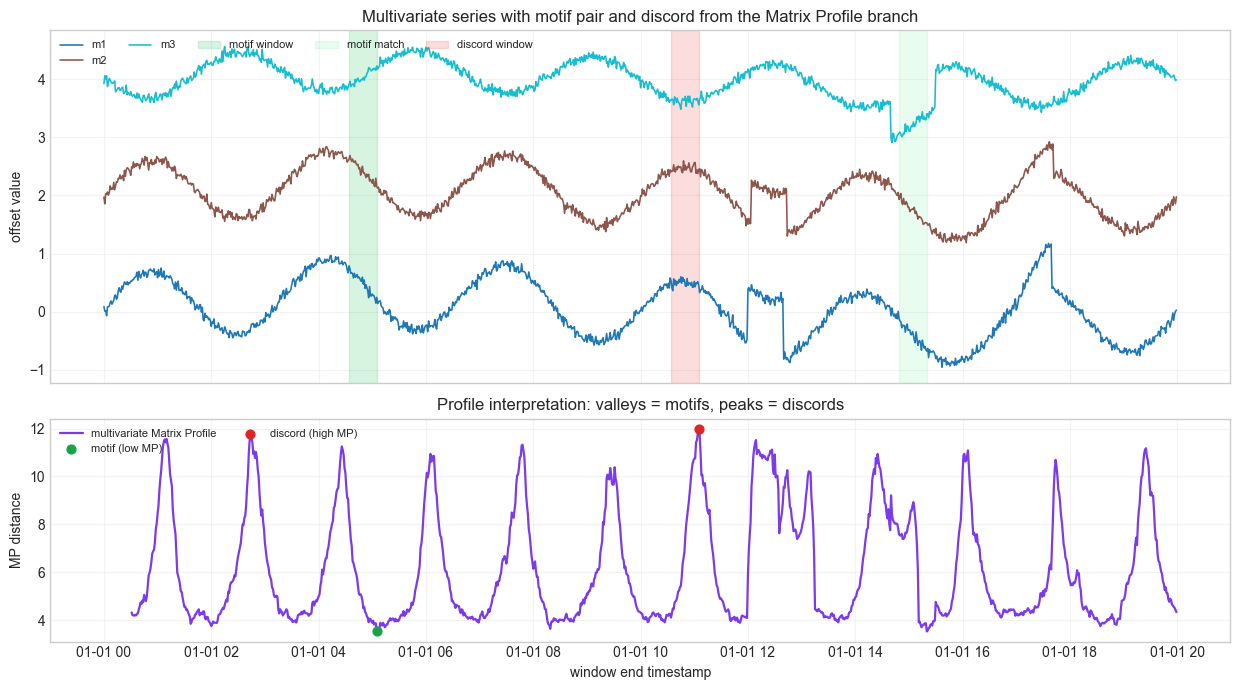

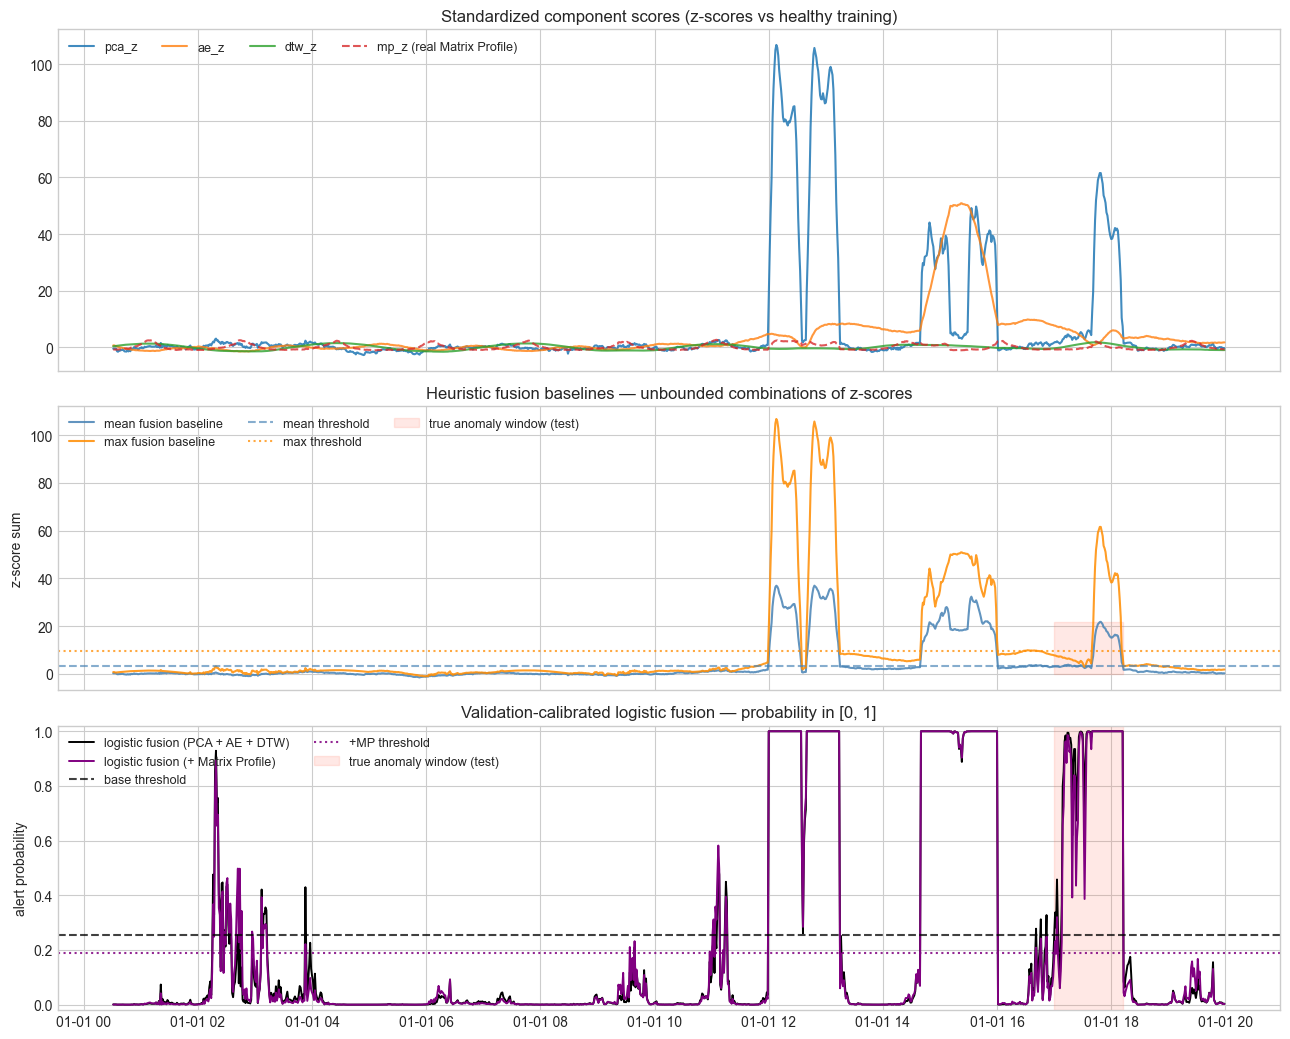

          timestamp     pca_z      ae_z     dtw_z      mp_z  mean_fusion  max_fusion  fused_base  fused_with_mp  label top_component
2024-01-01 12:53:00 93.617241  6.956876 -0.358529  0.803725    33.405196   93.617241         1.0            1.0      1         pca_z
2024-01-01 13:08:00 91.069984  8.178858 -0.426822  1.875781    32.940673   91.069984         1.0            1.0      1         pca_z
2024-01-01 17:41:00 19.554491  0.762804  1.778912  1.004083     7.365402   19.554491         1.0            1.0      1         pca_z
2024-01-01 14:41:00 26.459280  9.184166  0.819495  1.097036    12.154314   26.459280         1.0            1.0      1         pca_z
2024-01-01 14:42:00 29.795536 10.211532  0.821456  0.979014    13.609508   29.795536         1.0            1.0      1         pca_z
2024-01-01 14:43:00 28.998852 11.278893  0.822488  0.948724    13.700078   28.998852         1.0            1.0      1         pca_z
2024-01-01 14:44:00 31.975824 12.754349  0.827755  0.920018    15.185

In [16]:
mp_fig = plot_multivariate_matrix_profile_overview(panel_df, metric_cols, window=X.shape[1], mp=mp_scores, mp_index=mp_neighbor_idx)
plt.tight_layout()
if EXPORT_FIGURES:
    mp_fig.savefig(FIG_DIR / 'day4_multivariate_matrix_profile_demo.png', dpi=160, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(3, 1, figsize=(13, 10.5), sharex=True,
                         gridspec_kw={'height_ratios': [1.2, 1.0, 1.0]})

axes[0].plot(data['end_index'], component_frame['pca_z'], label='pca_z', alpha=0.85)
axes[0].plot(data['end_index'], component_frame['ae_z'], label='ae_z', alpha=0.80)
axes[0].plot(data['end_index'], component_frame['dtw_z'], label='dtw_z', alpha=0.80)
axes[0].plot(data['end_index'], component_frame['mp_z'], label='mp_z (real Matrix Profile)', alpha=0.78, linestyle='--')
axes[0].legend(loc='upper left', ncol=4, fontsize=9)
axes[0].set_title('Standardized component scores (z-scores vs healthy training)')

def shade_anomalies(ax, score):
    ax.fill_between(
        data['end_index'][test_idx],
        score[test_idx].min() - 0.02,
        score[test_idx].max() + 0.02,
        where=y[test_idx].astype(bool),
        color='tomato',
        alpha=0.14,
        label='true anomaly window (test)',
    )

axes[1].plot(data['end_index'], mean_fusion, label='mean fusion baseline', color='steelblue', alpha=0.85)
axes[1].plot(data['end_index'], max_fusion, label='max fusion baseline', color='darkorange', alpha=0.85)
axes[1].axhline(thresholds['mean_fusion'], linestyle='--', color='steelblue', alpha=0.65, label='mean threshold')
axes[1].axhline(thresholds['max_fusion'], linestyle=':', color='darkorange', alpha=0.75, label='max threshold')
shade_anomalies(axes[1], np.concatenate([mean_fusion, max_fusion]))
axes[1].legend(loc='upper left', ncol=3, fontsize=9)
axes[1].set_ylabel('z-score sum')
axes[1].set_title('Heuristic fusion baselines — unbounded combinations of z-scores')

axes[2].plot(data['end_index'], fused_base, label='logistic fusion (PCA + AE + DTW)', color='black', lw=1.4)
axes[2].plot(data['end_index'], fused_with_mp, label='logistic fusion (+ Matrix Profile)', color='purple', lw=1.4)
axes[2].axhline(thresholds['fused_logistic_base'], linestyle='--', color='black', alpha=0.75, label='base threshold')
axes[2].axhline(thresholds['fused_logistic_with_mp'], linestyle=':', color='purple', alpha=0.85, label='+MP threshold')
shade_anomalies(axes[2], np.concatenate([fused_base, fused_with_mp]))
axes[2].set_ylim(-0.02, 1.02)
axes[2].set_ylabel('alert probability')
axes[2].legend(loc='upper left', ncol=2, fontsize=9)
axes[2].set_title('Validation-calibrated logistic fusion — probability in [0, 1]')

plt.tight_layout()
if EXPORT_FIGURES:
    fig.savefig(FIG_DIR / 'day4_component_fusion.png', dpi=160, bbox_inches='tight')
plt.show()

component_review = pd.DataFrame({
    'timestamp': data['end_index'],
    'pca_z': component_frame['pca_z'],
    'ae_z': component_frame['ae_z'],
    'dtw_z': component_frame['dtw_z'],
    'mp_z': component_frame['mp_z'],
    'mean_fusion': mean_fusion,
    'max_fusion': max_fusion,
    'fused_base': fused_base,
    'fused_with_mp': fused_with_mp,
    'label': y,
})
component_review['top_component'] = component_review[['pca_z', 'ae_z', 'dtw_z', 'mp_z']].abs().idxmax(axis=1)
print(component_review.sort_values('fused_with_mp', ascending=False).head(10).to_string(index=False))
